# IoT Traffic Analysis v10-A — Packet-only (Burst windows)

v10-A replaces fixed time windows with **burst windows**: packets grouped until an idle gap > `GAP_SPLIT_S` occurs.

- This should reduce the throughput-bias seen in v9.
- Training budget is capped (v5-like) using `steps_per_epoch`.
- Direction is validated strictly via the filename MAC.

In [1]:
# If running in a fresh environment, install deps as needed:
# !pip install scapy tensorflow scikit-learn pandas numpy matplotlib

import os
import math
import random
import numpy as np
import pandas as pd
import re

from scapy.all import PcapReader
from scapy.layers.l2 import Ether, Dot3
from scapy.layers.inet import IP, TCP, UDP

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)


2026-01-18 14:29:55.666723: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-18 14:29:56.200817: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-18 14:29:59.225176: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.20.0


## 1) Dataset location

In [2]:
# === UPDATE THIS PATH ===
PCAP_DIR = "unsw-dataset/pcaps"   # e.g. "/content/pcaps" or "./pcaps"

assert os.path.isdir(PCAP_DIR), f"PCAP_DIR not found: {PCAP_DIR}"
pcap_files = sorted([os.path.join(PCAP_DIR, f) for f in os.listdir(PCAP_DIR) if f.endswith(".pcap")])

print("PCAP count:", len(pcap_files))
print("Example:", pcap_files[:3])


PCAP count: 27
Example: ['unsw-dataset/pcaps/AmazonEcho_44650d56ccd3.pcap', 'unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae.pcap', 'unsw-dataset/pcaps/AwairAirQuality_70886b100fc6.pcap']


## 2) Mapping

In [3]:
from collections import Counter

device_to_type_v7 = {
    "SamsungCamera_00166cab6b88": "camera_streamer",
    "BelkinCamera_b4750eece5a9": "camera_streamer",
    "NestDropCam_308cfb2fe4b2": "camera_streamer",
    "TPLinkCamera_f4f26D9351f1": "camera_streamer",
    "CanaryCamera_7c70bc5d5edc": "camera_streamer",
    "NetatmoWelcome_70ee50183443": "camera_streamer",
    "WithingsBabyMonitor_0024e41118a8": "camera_streamer",
    "RingDoorBell_884aea31669d": "camera_streamer",
    "AugustDoorBell_e076d03f00ae": "camera_streamer",

    "AwairAirQuality_70886b100fc6": "sensor_meter",
    "NetatmoWeatherStation_70ee5003b8ac": "sensor_meter",
    "WithingsSleepSensor_0024e42028c6": "sensor_meter",
    "WithingsSmartScale_0024e41b6f96": "sensor_meter",
    "BlipCareBPMeter_746a89002e25": "sensor_meter",
    "NestProtect_18b43025bee4": "sensor_meter",
    "BelkinWemoMotionSensor_ec1a59832811": "sensor_meter",

    "PhilipsHue_0017882b9a25": "actuator_light_plug",
    "LiFXBulb_d073d5018308": "actuator_light_plug",
    "TPLinkSmartPlug_50c7bf005639": "actuator_light_plug",
    "BelkinWemoSwitch_ec1a5979f489": "actuator_light_plug",

    "SamsungSmartThings_d052a800675e": "hub_gateway_bridge",
    "HPPrinter_705a0fe49bc0": "hub_gateway_bridge",

    "TribySpeaker_18B79E022044": "media_speaker_display",
    "PixStarPhotoFrame_e076d033bb85": "media_speaker_display",
    "HelloBarbie_28c2ddffa52d": "media_speaker_display",
    "iHome_74c63b29d71d": "media_speaker_display",
    "AmazonEcho_44650d56ccd3": "media_speaker_display",
}

v7_to_v8 = {
    "camera_streamer": "continuous_streaming",
    "sensor_meter": "low_rate_telemetry",
    "actuator_light_plug": "interactive_actuators",
    "media_speaker_display": "smart_media_clients",
    "hub_gateway_bridge": None,  # excluded
}

device_to_type = {dev: v7_to_v8.get(t, None) for dev, t in device_to_type_v7.items()}

DROP_NONE_TYPES = True
target_types = sorted([t for t in set(device_to_type.values()) if t is not None])
print("v10 target types:", target_types)
print("Counts:", Counter([t for t in device_to_type.values() if t is not None]))


v10 target types: ['continuous_streaming', 'interactive_actuators', 'low_rate_telemetry', 'smart_media_clients']
Counts: Counter({'continuous_streaming': 9, 'low_rate_telemetry': 7, 'smart_media_clients': 5, 'interactive_actuators': 4})


## 3) Build device table

In [4]:
def device_id_from_path(pcap_path: str) -> str:
    return os.path.basename(pcap_path).replace(".pcap", "")

rows = []
for p in pcap_files:
    dev = device_id_from_path(p)
    t = device_to_type.get(dev, None)
    if DROP_NONE_TYPES and t is None:
        continue
    if t is None:
        t = "unknown_infrastructure"
    rows.append({"device_id": dev, "device_type": t, "pcap_path": p})

df_dev = pd.DataFrame(rows).sort_values(["device_type", "device_id"]).reset_index(drop=True)
print("Devices included:", len(df_dev))
display(df_dev.head(10))
print(df_dev["device_type"].value_counts())


Devices included: 23


,device_id,device_type,pcap_path
0,AugustDoorBell_e076d03f00ae,continuous_streaming,unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae...
1,BelkinCamera_b4750eece5a9,continuous_streaming,unsw-dataset/pcaps/BelkinCamera_b4750eece5a9.pcap
2,CanaryCamera_7c70bc5d5edc,continuous_streaming,unsw-dataset/pcaps/CanaryCamera_7c70bc5d5edc.pcap
3,NestDropCam_308cfb2fe4b2,continuous_streaming,unsw-dataset/pcaps/NestDropCam_308cfb2fe4b2.pcap
4,NetatmoWelcome_70ee50183443,continuous_streaming,unsw-dataset/pcaps/NetatmoWelcome_70ee50183443...
5,RingDoorBell_884aea31669d,continuous_streaming,unsw-dataset/pcaps/RingDoorBell_884aea31669d.pcap
6,SamsungCamera_00166cab6b88,continuous_streaming,unsw-dataset/pcaps/SamsungCamera_00166cab6b88....
7,TPLinkCamera_f4f26D9351f1,continuous_streaming,unsw-dataset/pcaps/TPLinkCamera_f4f26D9351f1.pcap
8,BelkinWemoSwitch_ec1a5979f489,interactive_actuators,unsw-dataset/pcaps/BelkinWemoSwitch_ec1a5979f4...
9,LiFXBulb_d073d5018308,interactive_actuators,unsw-dataset/pcaps/LiFXBulb_d073d5018308.pcap


device_type
continuous_streaming     8
low_rate_telemetry       6
smart_media_clients      5
interactive_actuators    4
Name: count, dtype: int64


## 4) Train/test split by device

In [5]:
types = sorted(df_dev["device_type"].unique())
type_to_idx = {t: i for i, t in enumerate(types)}
idx_to_type = {i: t for t, i in type_to_idx.items()}
df_dev["y"] = df_dev["device_type"].map(type_to_idx).astype(int)

train_df, test_df = train_test_split(
    df_dev,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df_dev["device_type"]
)

print("Train devices:", len(train_df), "Test devices:", len(test_df))
print("Train distribution:\n", train_df["device_type"].value_counts())
print("Test distribution:\n", test_df["device_type"].value_counts())


Train devices: 16 Test devices: 7
Train distribution:
 device_type
continuous_streaming     6
low_rate_telemetry       4
interactive_actuators    3
smart_media_clients      3
Name: count, dtype: int64
Test distribution:
 device_type
continuous_streaming     2
smart_media_clients      2
low_rate_telemetry       2
interactive_actuators    1
Name: count, dtype: int64


## 5) Strict direction preflight (filename MAC must be present)

In [6]:
from collections import defaultdict

def _get_l2(pkt):
    if pkt.haslayer(Ether):
        return pkt[Ether]
    if pkt.haslayer(Dot3):
        return pkt[Dot3]
    raise RuntimeError("No Ether/Dot3 layer found (no MAC visible to Scapy).")

def mac_from_device_id(device_id: str) -> str:
    tail = device_id.split("_")[-1].lower()
    if not re.fullmatch(r"[0-9a-f]{12}", tail):
        raise RuntimeError(f"Cannot parse MAC from device_id: {device_id} (tail={tail})")
    return ":".join([tail[i:i+2] for i in range(0, 12, 2)])

def validate_filename_mac_in_pcap_strict(pcap_path: str, device_id: str, scan_packets: int = 8000, min_hits: int = 50):
    expected = mac_from_device_id(device_id)
    hits = 0
    total_l2 = 0
    with PcapReader(pcap_path) as pcap:
        for i, pkt in enumerate(pcap):
            l2 = _get_l2(pkt)  # strict
            total_l2 += 1
            src = str(getattr(l2, "src", "")).lower()
            dst = str(getattr(l2, "dst", "")).lower()
            if src == expected or dst == expected:
                hits += 1
            if i + 1 >= scan_packets:
                break
    if total_l2 == 0:
        raise RuntimeError(f"No L2 frames decoded for {device_id} ({pcap_path})")
    if hits < min_hits:
        raise RuntimeError(
            f"Filename MAC not observed enough for {device_id}. expected={expected} hits={hits} (<{min_hits}) file={pcap_path}"
        )
    return expected, hits

device_mac_map = {}
for _, row in df_dev.iterrows():
    dev = row["device_id"]
    p = row["pcap_path"]
    mac, hits = validate_filename_mac_in_pcap_strict(p, dev)
    device_mac_map[dev] = mac

print("Preflight OK. Example:", list(device_mac_map.items())[:3])


Preflight OK. Example: [('AugustDoorBell_e076d03f00ae', 'e0:76:d0:3f:00:ae'), ('BelkinCamera_b4750eece5a9', 'b4:75:0e:ec:e5:a9'), ('CanaryCamera_7c70bc5d5edc', '7c:70:bc:5d:5e:dc')]


## 6) v10-A burst windowing + features

In [7]:
# v10-A: event-driven (burst) windows, split by idle gaps > GAP_SPLIT_S.

GAP_SPLIT_S = 2.0
MAX_BURSTS_PER_DEVICE = 3000

T_MAX = 256
MTU_NORM = 1500.0

Fp = 19  # 8 base + 4 proto + 6 flags + 1 keepalive
Fs = 20  # see summarize_burst() for exact ordering

def safe_payload_len(pkt) -> int:
    if pkt.haslayer(TCP):
        return int(len(bytes(pkt[TCP].payload)))
    if pkt.haslayer(UDP):
        return int(len(bytes(pkt[UDP].payload)))
    return 0

def tcp_flag_bits(tcp_layer) -> np.ndarray:
    def has(flag_char):
        return 1.0 if flag_char in str(tcp_layer.flags) else 0.0
    return np.array([has("S"), has("A"), has("F"), has("R"), has("P"), has("U")], dtype=np.float32)

def is_keepalive_like(pkt) -> float:
    if not pkt.haslayer(TCP):
        return 0.0
    pl = safe_payload_len(pkt)
    if pl > 1:
        return 0.0
    fl = str(pkt[TCP].flags)
    if ("A" in fl) and ("S" not in fl) and ("F" not in fl) and ("R" not in fl) and len(pkt) <= 80:
        return 1.0
    return 0.0

def log1p_clip(x: float, cap: float = 600.0) -> float:
    x = min(max(x, 0.0), cap)
    return math.log1p(x)

def pad_or_trim_pkt_feats(pkt_feats: list, t_max: int = T_MAX) -> np.ndarray:
    if len(pkt_feats) >= t_max:
        arr = np.stack(pkt_feats[:t_max], axis=0).astype(np.float32)
    else:
        arr = np.zeros((t_max, Fp), dtype=np.float32)
        if len(pkt_feats) > 0:
            arr[:len(pkt_feats), :] = np.stack(pkt_feats, axis=0).astype(np.float32)
    return arr

def summarize_burst(items: list, device_mac: str | None, no_direction: bool, pre_idle: float) -> np.ndarray:
    n = len(items)
    if n == 0:
        return np.zeros((Fs,), dtype=np.float32)

    t0 = items[0]["t"]
    t1 = items[-1]["t"]
    dur = max(t1 - t0, 1e-6)

    total_bytes = float(sum(it["plen"] for it in items))
    total_pkts = float(n)
    pps = total_pkts / dur
    bps = total_bytes / dur

    iats = [items[i]["t"] - items[i-1]["t"] for i in range(1, n)] if n > 1 else [0.0]
    iat_mean = float(np.mean(iats)) if iats else 0.0
    iat_p90 = float(np.percentile(iats, 90)) if len(iats) >= 2 else iat_mean
    iat_max = float(np.max(iats)) if iats else 0.0
    frac_gt_01 = sum(1 for x in iats if x > 0.1) / max(len(iats), 1)
    frac_gt_1 = sum(1 for x in iats if x > 1.0) / max(len(iats), 1)

    tcp = sum(1 for it in items if it["proto"] == "tcp")
    udp = sum(1 for it in items if it["proto"] == "udp")
    icmp = sum(1 for it in items if it["proto"] == "icmp")
    other = n - tcp - udp - icmp

    dns_like = sum(1 for it in items if it["dns_like"])
    tls_like = sum(1 for it in items if it["tls_like"])

    unique_dsts = len(set(it["dst"] for it in items if it["dst"] is not None))

    if no_direction or device_mac is None:
        asym_bytes = 0.0
    else:
        up_bytes = sum(it["plen"] for it in items if it["dir"] == 1.0)
        down_bytes = total_bytes - up_bytes
        asym_bytes = (up_bytes - down_bytes) / (total_bytes + 1e-6)

    pre_idle = max(pre_idle, 0.0)
    is_long_idle = 1.0 if pre_idle > 5.0 else 0.0

    feat = np.array([
        math.log1p(total_pkts),                 # 0
        math.log1p(total_bytes),                # 1
        math.log1p(dur),                        # 2
        math.log1p(pps),                        # 3
        math.log1p(bps),                        # 4
        log1p_clip(iat_mean),                   # 5
        log1p_clip(iat_p90),                    # 6
        log1p_clip(iat_max),                    # 7
        frac_gt_01,                             # 8
        frac_gt_1,                              # 9
        tcp / n,                                # 10
        udp / n,                                # 11
        icmp / n,                               # 12
        other / n,                              # 13
        dns_like / n,                           # 14
        tls_like / n,                           # 15
        math.log1p(unique_dsts),                # 16
        asym_bytes,                             # 17
        log1p_clip(pre_idle),                   # 18
        is_long_idle,                           # 19
    ], dtype=np.float32)

    assert feat.shape[0] == Fs, f"summary dim={feat.shape[0]} expected Fs={Fs}"
    return feat

def iter_bursts(pcap_path: str, device_id: str, label: int, no_direction: bool, max_bursts: int = MAX_BURSTS_PER_DEVICE):
    device_mac = device_mac_map[device_id]
    bursts_yielded = 0

    cur_items = []
    cur_pkt_feats = []
    burst_start = None
    last_time = None
    last_pkt_time_prev_burst = None

    with PcapReader(pcap_path) as pcap:
        for pkt in pcap:
            if not pkt.haslayer(IP):
                continue
            l2 = _get_l2(pkt)

            t = float(getattr(pkt, "time", 0.0))
            if last_time is None:
                gap = 0.0
            else:
                gap = max(0.0, t - last_time)

            if cur_items and gap > GAP_SPLIT_S:
                pre_idle = 0.0 if last_pkt_time_prev_burst is None else max(0.0, burst_start - last_pkt_time_prev_burst)
                X_pkt = pad_or_trim_pkt_feats(cur_pkt_feats, t_max=T_MAX)
                X_sum = summarize_burst(cur_items, device_mac=device_mac, no_direction=no_direction, pre_idle=pre_idle)
                yield X_pkt, X_sum, label

                bursts_yielded += 1
                if bursts_yielded >= max_bursts:
                    break

                last_pkt_time_prev_burst = cur_items[-1]["t"]
                cur_items = []
                cur_pkt_feats = []
                burst_start = None

            if burst_start is None:
                burst_start = t

            ip = pkt[IP]
            plen = float(len(pkt))
            payload_len = float(safe_payload_len(pkt))
            ttl = float(getattr(ip, "ttl", 0.0))

            if last_time is None:
                iat = 0.0
            else:
                iat = gap
            last_time = t

            direction = 0.0
            if not no_direction:
                direction = 1.0 if str(l2.src).lower() == device_mac else 0.0

            rel_t = (t - burst_start) / max(GAP_SPLIT_S * 20.0, 1e-6)
            rel_t = float(min(max(rel_t, 0.0), 10.0))

            proto = int(getattr(ip, "proto", 0))
            if proto == 6:
                proto_oh = np.array([1.0, 0.0, 0.0, 0.0], dtype=np.float32)
                proto_name = "tcp"
            elif proto == 17:
                proto_oh = np.array([0.0, 1.0, 0.0, 0.0], dtype=np.float32)
                proto_name = "udp"
            elif proto == 1:
                proto_oh = np.array([0.0, 0.0, 1.0, 0.0], dtype=np.float32)
                proto_name = "icmp"
            else:
                proto_oh = np.array([0.0, 0.0, 0.0, 1.0], dtype=np.float32)
                proto_name = "other"

            flags = np.zeros(6, dtype=np.float32)
            dns_like = tls_like = False

            if pkt.haslayer(TCP):
                tcp = pkt[TCP]
                flags = tcp_flag_bits(tcp)
                sport = int(getattr(tcp, "sport", 0))
                dport = int(getattr(tcp, "dport", 0))
                dns_like = (sport == 53 or dport == 53)
                tls_like = (sport == 443 or dport == 443)
            elif pkt.haslayer(UDP):
                udp = pkt[UDP]
                sport = int(getattr(udp, "sport", 0))
                dport = int(getattr(udp, "dport", 0))
                dns_like = (sport == 53 or dport == 53)
                tls_like = False

            keepalive = is_keepalive_like(pkt)

            pkt_len_norm = min(plen / MTU_NORM, 4.0)
            payload_norm = min(payload_len / MTU_NORM, 4.0)
            ttl_norm = ttl / 255.0
            iat_log = log1p_clip(iat, cap=600.0) / log1p_clip(600.0, cap=600.0)
            iat_big = 1.0 if iat > 0.1 else 0.0
            iat_huge = 1.0 if iat > 1.0 else 0.0

            pkt_feat = np.concatenate([
                np.array([pkt_len_norm, payload_norm, iat_log, direction, ttl_norm, rel_t, iat_big, iat_huge], dtype=np.float32),
                proto_oh,
                flags,
                np.array([keepalive], dtype=np.float32),
            ], axis=0).astype(np.float32)

            assert pkt_feat.shape[0] == Fp, f"pkt_feat dim={pkt_feat.shape[0]} expected Fp={Fp}"

            cur_items.append({
                "t": t,
                "plen": plen,
                "proto": proto_name,
                "dst": getattr(ip, "dst", None),
                "dir": direction,
                "dns_like": dns_like,
                "tls_like": tls_like,
            })
            cur_pkt_feats.append(pkt_feat)

    if cur_items:
        pre_idle = 0.0 if last_pkt_time_prev_burst is None else max(0.0, burst_start - last_pkt_time_prev_burst)
        X_pkt = pad_or_trim_pkt_feats(cur_pkt_feats, t_max=T_MAX)
        X_sum = summarize_burst(cur_items, device_mac=device_mac, no_direction=no_direction, pre_idle=pre_idle)
        yield X_pkt, X_sum, label


## 7) Training budget (v5-like)

In [8]:
# v10 training budget: similar to v5 (cap steps per epoch)
EPOCHS = 5
TRAIN_STEPS_PER_EPOCH = 500
VAL_STEPS = 150


## 8) Model + train + evaluate

2026-01-18 14:31:03.459723: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pkt_features (InputLayer)       │ (None, 256, 19)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 256, 64)        │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,996 (707.02 KB)

 Trainable params: 180,100 (703.52 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3196s 6s/step - accuracy: 0.9263 - loss: 0.2663 - val_accuracy: 0.3130 - val_loss: 2.4267
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1874s 4s/step - accuracy: 0.9349 - loss: 0.2594 - val_accuracy: 0.2285 - val_loss: 5.8319
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 4393s 9s/step - accuracy: 0.9575 - loss: 0.1583 - val_accuracy: 0.1065 - val_loss: 16.3738


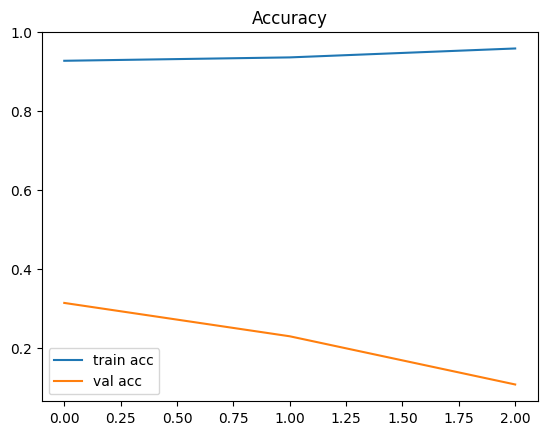

Burst-level classification report:
                       precision    recall  f1-score   support

 continuous_streaming     0.3534    0.9950    0.5215       402
interactive_actuators     0.0000    0.0000    0.0000       201
   low_rate_telemetry     0.1500    0.0136    0.0250       220
  smart_media_clients     0.0000    0.0000    0.0000       329

             accuracy                         0.3498      1152
            macro avg     0.1258    0.2522    0.1366      1152
         weighted avg     0.1520    0.3498    0.1868      1152



/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

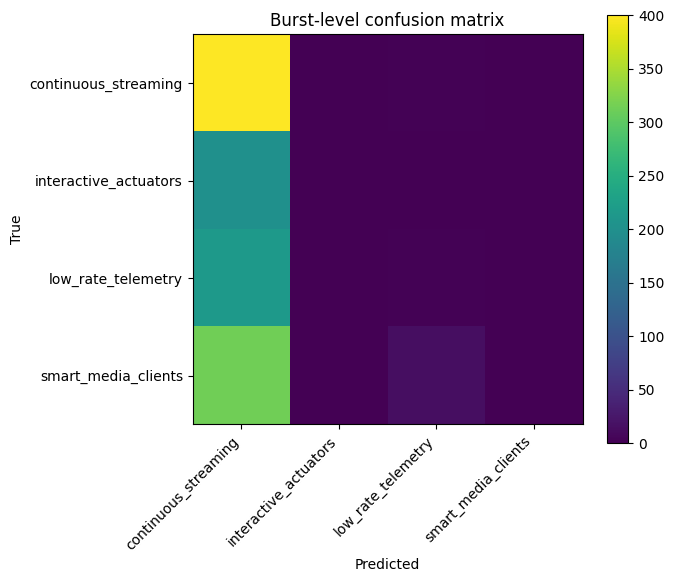


Per-device predictions:
- NestDropCam_308cfb2fe4b2            true=continuous_streaming   pred=continuous_streaming   bursts=201
- PixStarPhotoFrame_e076d033bb85      true=smart_media_clients    pred=continuous_streaming   bursts=201
- PhilipsHue_0017882b9a25             true=interactive_actuators  pred=continuous_streaming   bursts=201
- BlipCareBPMeter_746a89002e25        true=low_rate_telemetry     pred=continuous_streaming   bursts=19
- HelloBarbie_28c2ddffa52d            true=smart_media_clients    pred=continuous_streaming   bursts=128
- WithingsSmartScale_0024e41b6f96     true=low_rate_telemetry     pred=continuous_streaming   bursts=201
- SamsungCamera_00166cab6b88          true=continuous_streaming   pred=continuous_streaming   bursts=201

Device-level classification report (mean-prob aggregation):
                       precision    recall  f1-score   support

 continuous_streaming     0.2857    1.0000    0.4444         2
interactive_actuators     0.0000    0.0000    0.0000 

/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

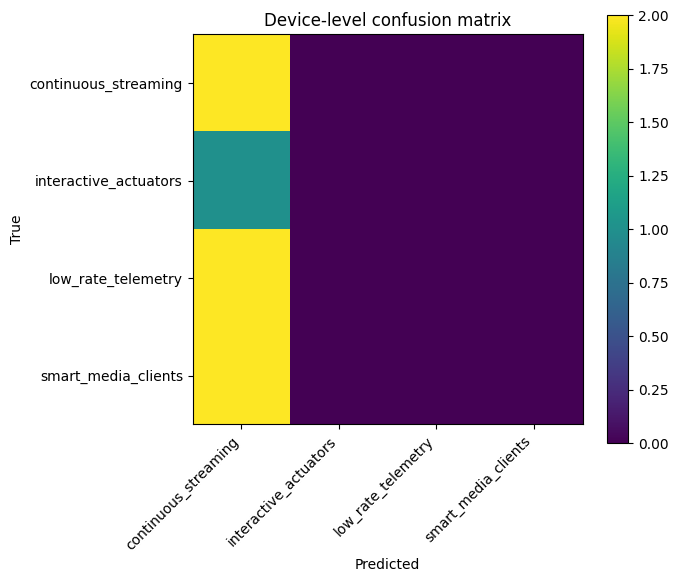

In [9]:
def make_pkt_cnn(n_classes: int) -> tf.keras.Model:
    inp = layers.Input(shape=(T_MAX, Fp), name="pkt_features")
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(2)(x)

    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(2)(x)

    x = layers.Conv1D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.25)(x)

    out = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


def make_ds_packet(df_sub: pd.DataFrame, no_direction: bool, batch_size: int = 64, shuffle: bool = True):
    def gen():
        for _, row in df_sub.iterrows():
            dev = row["device_id"]
            y = int(row["y"])
            p = row["pcap_path"]
            for Xpkt, Xsum, y_ in iter_bursts(p, device_id=dev, label=y, no_direction=no_direction):
                yield Xpkt, y_
    out_sig = (
        tf.TensorSpec(shape=(T_MAX, Fp), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    ds = tf.data.Dataset.from_generator(gen, output_signature=out_sig)
    if shuffle:
        ds = ds.shuffle(2048, seed=RANDOM_STATE, reshuffle_each_iteration=True)
    ds = ds.repeat()
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def make_ds_summary(df_sub: pd.DataFrame, no_direction: bool, batch_size: int = 128, shuffle: bool = True):
    def gen():
        for _, row in df_sub.iterrows():
            dev = row["device_id"]
            y = int(row["y"])
            p = row["pcap_path"]
            for Xpkt, Xsum, y_ in iter_bursts(p, device_id=dev, label=y, no_direction=no_direction):
                yield Xsum, y_
    out_sig = (
        tf.TensorSpec(shape=(Fs,), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    ds = tf.data.Dataset.from_generator(gen, output_signature=out_sig)
    if shuffle:
        ds = ds.shuffle(4096, seed=RANDOM_STATE, reshuffle_each_iteration=True)
    ds = ds.repeat()
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def make_ds_two(df_sub: pd.DataFrame, no_direction: bool, batch_size: int = 64, shuffle: bool = True):
    def gen():
        for _, row in df_sub.iterrows():
            dev = row["device_id"]
            y = int(row["y"])
            p = row["pcap_path"]
            for Xpkt, Xsum, y_ in iter_bursts(p, device_id=dev, label=y, no_direction=no_direction):
                yield (Xpkt, Xsum), y_
    out_sig = (
        (tf.TensorSpec(shape=(T_MAX, Fp), dtype=tf.float32),
         tf.TensorSpec(shape=(Fs,), dtype=tf.float32)),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    ds = tf.data.Dataset.from_generator(gen, output_signature=out_sig)
    if shuffle:
        ds = ds.shuffle(2048, seed=RANDOM_STATE, reshuffle_each_iteration=True)
    ds = ds.repeat()
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def collect_preds_packet_only(df_sub: pd.DataFrame, model: tf.keras.Model, no_direction: bool, max_bursts_per_device: int = 200):
    all_true, all_pred, per_device = [], [], []
    for _, row in df_sub.iterrows():
        dev = row["device_id"]
        y_true = int(row["y"])
        p = row["pcap_path"]
        probs = []
        bcount = 0
        for Xpkt, Xsum, y_ in iter_bursts(p, device_id=dev, label=y_true, no_direction=no_direction, max_bursts=max_bursts_per_device):
            pr = model.predict(Xpkt[None, ...], verbose=0)[0]
            probs.append(pr)
            y_hat = int(np.argmax(pr))
            all_true.append(y_true); all_pred.append(y_hat)
            bcount += 1
        if probs:
            probs_mean = np.mean(np.stack(probs, axis=0), axis=0)
            y_dev = int(np.argmax(probs_mean))
        else:
            probs_mean = np.zeros((len(types),), dtype=np.float32); y_dev = -1
        per_device.append((dev, y_true, probs_mean, y_dev, bcount))
    return np.array(all_true), np.array(all_pred), per_device

def collect_preds_summary_only(df_sub: pd.DataFrame, model: tf.keras.Model, no_direction: bool, max_bursts_per_device: int = 200):
    all_true, all_pred, per_device = [], [], []
    for _, row in df_sub.iterrows():
        dev = row["device_id"]
        y_true = int(row["y"])
        p = row["pcap_path"]
        probs = []
        bcount = 0
        for Xpkt, Xsum, y_ in iter_bursts(p, device_id=dev, label=y_true, no_direction=no_direction, max_bursts=max_bursts_per_device):
            pr = model.predict(Xsum[None, ...], verbose=0)[0]
            probs.append(pr)
            y_hat = int(np.argmax(pr))
            all_true.append(y_true); all_pred.append(y_hat)
            bcount += 1
        if probs:
            probs_mean = np.mean(np.stack(probs, axis=0), axis=0)
            y_dev = int(np.argmax(probs_mean))
        else:
            probs_mean = np.zeros((len(types),), dtype=np.float32); y_dev = -1
        per_device.append((dev, y_true, probs_mean, y_dev, bcount))
    return np.array(all_true), np.array(all_pred), per_device

def collect_preds_two_branch(df_sub: pd.DataFrame, model: tf.keras.Model, no_direction: bool, max_bursts_per_device: int = 200):
    all_true, all_pred, per_device = [], [], []
    for _, row in df_sub.iterrows():
        dev = row["device_id"]
        y_true = int(row["y"])
        p = row["pcap_path"]
        probs = []
        bcount = 0
        for Xpkt, Xsum, y_ in iter_bursts(p, device_id=dev, label=y_true, no_direction=no_direction, max_bursts=max_bursts_per_device):
            pr = model.predict([Xpkt[None, ...], Xsum[None, ...]], verbose=0)[0]
            probs.append(pr)
            y_hat = int(np.argmax(pr))
            all_true.append(y_true); all_pred.append(y_hat)
            bcount += 1
        if probs:
            probs_mean = np.mean(np.stack(probs, axis=0), axis=0)
            y_dev = int(np.argmax(probs_mean))
        else:
            probs_mean = np.zeros((len(types),), dtype=np.float32); y_dev = -1
        per_device.append((dev, y_true, probs_mean, y_dev, bcount))
    return np.array(all_true), np.array(all_pred), per_device


def show_reports(win_true, win_pred, dev_preds):
    print("Burst-level classification report:")
    print(classification_report(win_true, win_pred, target_names=types, digits=4))

    cm = confusion_matrix(win_true, win_pred, labels=list(range(n_classes)))
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Burst-level confusion matrix")
    plt.colorbar()
    plt.xticks(range(n_classes), types, rotation=45, ha="right")
    plt.yticks(range(n_classes), types)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    dev_true = []
    dev_pred = []
    print("\nPer-device predictions:")
    for dev, y_true, probs_mean, y_dev, bcount in dev_preds:
        if y_dev >= 0:
            dev_true.append(y_true)
            dev_pred.append(y_dev)
        print(f"- {dev:35s} true={idx_to_type[y_true]:22s} pred={idx_to_type.get(y_dev,'(none)'):22s} bursts={bcount}")

    dev_true = np.array(dev_true)
    dev_pred = np.array(dev_pred)

    print("\nDevice-level classification report (mean-prob aggregation):")
    print(classification_report(dev_true, dev_pred, target_names=types, digits=4))

    cm2 = confusion_matrix(dev_true, dev_pred, labels=list(range(n_classes)))
    plt.figure(figsize=(7, 6))
    plt.imshow(cm2, interpolation="nearest")
    plt.title("Device-level confusion matrix")
    plt.colorbar()
    plt.xticks(range(n_classes), types, rotation=45, ha="right")
    plt.yticks(range(n_classes), types)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


n_classes = len(types)
model = make_pkt_cnn(n_classes)
model.summary()

NO_DIRECTION = False

train_ds = make_ds_packet(train_df, no_direction=NO_DIRECTION, batch_size=64, shuffle=True)
val_ds   = make_ds_packet(test_df,  no_direction=NO_DIRECTION, batch_size=64, shuffle=False)

callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=TRAIN_STEPS_PER_EPOCH,
    validation_steps=VAL_STEPS,
    callbacks=callbacks
)

plt.figure()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend(); plt.title("Accuracy"); plt.show()

win_true, win_pred, dev_preds = collect_preds_packet_only(test_df, model, no_direction=NO_DIRECTION, max_bursts_per_device=200)
n_classes = len(types)
show_reports(win_true, win_pred, dev_preds)
